## Baselines e Seleção de Features
### Café Arábica (KC=F): ARIMA, GARCH, ablação de clima e seleção dentro do fold

Este notebook **complementa** `lstm_coffee_price.ipynb` (não o altera). Ele reusa
**exatamente o mesmo protocolo** de validação temporal — mesmos folds walk-forward,
mesmo `LOOKBACK`/`EMBARGO`, mesmo `StandardScaler` por fold, e as **mesmas funções
de janelamento e métricas** — para que LSTM e baselines sejam julgados sob condições
idênticas, nos **mesmos dias-alvo** (`te_idx[LOOKBACK:]` de cada fold).

Conteúdo:
1. **ARIMA** (baseline de média) — ordem por AIC no treino, previsão recursiva 1-passo.
2. **GARCH(1,1)** (baseline de *volatilidade*, não do nível) — QLIKE/MSE da variância.
3. **Seleção de features dentro do fold** (importância de Random Forest, top-k).
4. **Ablação do clima** — LSTM com (a) só mercado, (b) mercado+clima bruto, (c) mercado+clima defasado.
5. **Tabela comparativa única** + resumo.

> Convenção de Diebold–Mariano usada aqui: `DM = mean(e_modelo^2 - e_ref^2) / sd`.
> **DM < -1,96 ⇒ o modelo é significativamente melhor que a referência** (erro menor); DM > 1,96 ⇒ pior.

# 1. Imports e configuração

In [1]:
import warnings, os, time
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)
DPI = 150

Device: cuda


# 2. Dados, alvo e features
Replicado de `lstm_coffee_price.ipynb` para garantir o **mesmo `df` e as mesmas colunas**.
Alvo: log-retorno do fechamento (estacionário).

In [2]:
df = pd.read_csv("data/dataset_final.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)
df["log_preco"]  = np.log(df["preco_cafe"])
df["ret_cafe"]   = df["log_preco"].diff()
df["ret_cambio"] = np.log(df["cambio_brl"]).diff()
df = df.dropna(subset=["ret_cafe", "ret_cambio"]).reset_index(drop=True)

# --- Mercado ---
df["vol_5"]  = df["ret_cafe"].rolling(5).std()
df["vol_21"] = df["ret_cafe"].rolling(21).std()
df["sma_10"] = df["ret_cafe"].rolling(10).mean()
# --- Agronômicas regionais (defasadas / acumuladas) ---
geada_cols = [c for c in df.columns if c.startswith("geada_risco")]
frio_cols  = [c for c in df.columns if c.startswith("graus_frio")]
df["geada_risco_any"] = df[geada_cols].max(axis=1)
df["geada_risco_30d"] = df["geada_risco_any"].rolling(30, min_periods=1).max()
df["graus_frio_max"]  = df[frio_cols].max(axis=1)
df["graus_frio_30d"]  = df["graus_frio_max"].rolling(30, min_periods=1).sum()
# --- Sazonalidade ---
doy = df["date"].dt.dayofyear
df["sin_doy"] = np.sin(2*np.pi*doy/365.25)
df["cos_doy"] = np.cos(2*np.pi*doy/365.25)
df = df.dropna().reset_index(drop=True)
print("df:", df.shape, "|", df["date"].min().date(), "->", df["date"].max().date())

df: (1742, 59) | 2019-01-31 -> 2025-12-30


# 3. Protocolo (idêntico ao da LSTM)
`LOOKBACK=45`, `EMBARGO=LOOKBACK`, `N_SPLITS=5`, treino expansivo a partir de 50% dos dados.
As funções abaixo são **cópias verbatim** do notebook da LSTM.

In [3]:
LOOKBACK = 45
HORIZON  = 1
EMBARGO  = LOOKBACK
N_SPLITS = 5
MIN_TRAIN = int(len(df) * 0.5)
TARGET = "ret_cafe"

# Conjuntos de features para a ablação
market      = ["ret_cafe", "ret_cambio", "vol_5", "vol_21", "sma_10", "sin_doy", "cos_doy"]
climate_raw = [c for c in df.columns if c.startswith((
    "temp_min_C_min_", "temp_ar_C_mean_", "umidade_pct_mean_",
    "precip_mm_sum_", "radiacao_kJm2_sum_"))]
climate_lag = ["geada_risco_any", "geada_risco_30d", "graus_frio_max", "graus_frio_30d"]

FEATURE_SETS = {
    "a_market":          market,
    "b_market_climaRaw": market + climate_raw,
    "c_market_climaLag": market + climate_lag,
}
ALL_FEATURES = list(dict.fromkeys(market + climate_raw + climate_lag))
print({k: len(v) for k, v in FEATURE_SETS.items()}, "| pool seleção:", len(ALL_FEATURES))

{'a_market': 7, 'b_market_climaRaw': 27, 'c_market_climaLag': 11} | pool seleção: 31


In [4]:
def make_windows(X, y, lookback, horizon=1):
    """X: (n, f) já escalado; y: (n,) alvo. Retorna (janelas, alvos)."""
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xs.append(X[i:i+lookback]); ys.append(y[i+lookback+horizon-1])
    return np.asarray(Xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)

def walk_forward_indices(n, n_splits, min_train, embargo):
    """(idx_treino, idx_teste) com janela de treino expansiva e embargo."""
    test_size = (n - min_train) // n_splits
    for k in range(n_splits):
        tr_end   = min_train + k * test_size
        te_start = tr_end + embargo
        te_end   = te_start + test_size if k < n_splits - 1 else n
        if te_start >= n: break
        yield np.arange(0, tr_end), np.arange(te_start, te_end)

# pré-computa os folds uma vez (todos os modelos usam exatamente estes)
FOLDS = list(walk_forward_indices(len(df), N_SPLITS, MIN_TRAIN, EMBARGO))
for f,(tr,te) in enumerate(FOLDS):
    print(f"fold {f}: treino[0:{tr[-1]+1}] teste[{te[0]}:{te[-1]+1}] (n_teste={len(te)}, n_eval={len(te)-LOOKBACK})")

fold 0: treino[0:871] teste[916:1090] (n_teste=174, n_eval=129)
fold 1: treino[0:1045] teste[1090:1264] (n_teste=174, n_eval=129)
fold 2: treino[0:1219] teste[1264:1438] (n_teste=174, n_eval=129)
fold 3: treino[0:1393] teste[1438:1612] (n_teste=174, n_eval=129)
fold 4: treino[0:1567] teste[1612:1742] (n_teste=130, n_eval=85)


# 4. Modelo LSTM e métricas (verbatim do notebook da LSTM)

In [5]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden=48, n_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=n_layers, batch_first=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.drop(out[:, -1, :])
        return self.head(out).squeeze(-1)

def train_one(model, Xtr, ytr, Xva, yva, epochs=150, lr=1e-3, patience=15, batch=32):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    lossf = nn.MSELoss()
    Xtr_t = torch.tensor(Xtr).to(device); ytr_t = torch.tensor(ytr).to(device)
    Xva_t = torch.tensor(Xva).to(device); yva_t = torch.tensor(yva).to(device)
    best, best_state, wait = float("inf"), None, 0
    n = len(Xtr_t)
    for ep in range(epochs):
        model.train(); perm = torch.randperm(n)
        for i in range(0, n, batch):
            idx = perm[i:i+batch]
            opt.zero_grad()
            loss = lossf(model(Xtr_t[idx]), ytr_t[idx])
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vl = lossf(model(Xva_t), yva_t).item()
        if vl < best:
            best, best_state, wait = vl, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience: break
    if best_state: model.load_state_dict(best_state)
    return model

In [6]:
def smape(y, yhat):
    d = (np.abs(y) + np.abs(yhat)); d[d == 0] = 1e-8
    return 100 * np.mean(2 * np.abs(yhat - y) / d)

def mase(y, yhat, y_train):
    naive = np.mean(np.abs(np.diff(y_train))); naive = naive if naive > 0 else 1e-8
    return mean_absolute_error(y, yhat) / naive

def directional_accuracy(y, yhat):
    return float(np.mean(np.sign(y) == np.sign(yhat)))

def diebold_mariano(y, p1, p2, h=1):
    e1, e2 = (y - p1)**2, (y - p2)**2
    d = e1 - e2; n = len(d); dbar = d.mean()
    gamma0 = np.mean((d - dbar)**2); var = gamma0 / n
    return float(dbar / np.sqrt(var)) if var > 0 else 0.0

def metric_row(name, fold, yte, pred, y_train):
    naive = np.zeros_like(yte)
    return {"model": name, "fold": fold, "n_test": len(yte),
            "RMSE": np.sqrt(mean_squared_error(yte, pred)),
            "RMSE_naive": np.sqrt(mean_squared_error(yte, naive)),
            "MAE": mean_absolute_error(yte, pred),
            "sMAPE": smape(yte, pred),
            "MASE": mase(yte, pred, y_train),
            "DirAcc": directional_accuracy(yte, pred),
            "DM_vs_naive": diebold_mariano(yte, pred, naive)}

# 5. Baseline ARIMA (média) — PRINCIPAL
Por fold: ordem `(p,0,q)` escolhida por **AIC no treino** (`d=0`, série estacionária);
parâmetros estimados uma vez, depois **previsão recursiva 1-passo** sobre o bloco de teste
alimentando os retornos realizados (sem refit, sem vazamento). Avaliado nos **mesmos dias**
que a LSTM (`te_idx[LOOKBACK:]`).

In [7]:
def select_arima_order(y, pmax=3, qmax=3):
    best_aic, best = np.inf, (1, 0, 0)
    for p in range(pmax+1):
        for q in range(qmax+1):
            if p == 0 and q == 0: continue
            try:
                r = ARIMA(y, order=(p,0,q), trend='c').fit(method_kwargs={"warn_convergence": False})
                if r.aic < best_aic: best_aic, best = r.aic, (p,0,q)
            except Exception:
                continue
    return best

def arima_fold(y_all, tr_idx, eval_pos):
    order = select_arima_order(y_all[tr_idx])
    hist = list(y_all[:eval_pos[0]])
    res = ARIMA(hist, order=order, trend='c').fit(method_kwargs={"warn_convergence": False})
    preds = []
    for p in eval_pos:
        preds.append(float(res.forecast(1)[0]))
        res = res.append([y_all[p]], refit=False)   # filtra com o realizado, mantém parâmetros
    return np.array(preds), order

y_all = df[TARGET].values
arima_rows, rw_rows = [], []
oos = {"true": [], "rw": [], "arima": []}
arima_orders = {}
fold_eval_pos = {}
for fold, (tr_idx, te_idx) in enumerate(FOLDS):
    eval_pos = te_idx[LOOKBACK+HORIZON-1:]
    fold_eval_pos[fold] = eval_pos
    yte = y_all[eval_pos]
    t0 = time.time()
    apred, order = arima_fold(y_all, tr_idx, eval_pos)
    arima_orders[fold] = order
    arima_rows.append(metric_row("ARIMA", fold, yte, apred, y_all[tr_idx]))
    rw_rows.append(metric_row("RandomWalk", fold, yte, np.zeros_like(yte), y_all[tr_idx]))
    oos["true"].append(yte); oos["rw"].append(np.zeros_like(yte)); oos["arima"].append(apred)
    print(f"fold {fold}: ARIMA{order} | RMSE {arima_rows[-1]['RMSE']:.5f} "
          f"(naive {arima_rows[-1]['RMSE_naive']:.5f}) | MASE {arima_rows[-1]['MASE']:.3f} "
          f"| {time.time()-t0:.1f}s")
for k in oos: oos[k] = np.concatenate(oos[k])
print("\nordens ARIMA por fold:", arima_orders)

fold 0: ARIMA(1, 0, 0) | RMSE 0.02211 (naive 0.02212) | MASE 0.719 | 1.6s


fold 1: ARIMA(1, 0, 0) | RMSE 0.02292 (naive 0.02295) | MASE 0.700 | 2.3s


fold 2: ARIMA(1, 0, 0) | RMSE 0.02391 (naive 0.02399) | MASE 0.774 | 2.3s


fold 3: ARIMA(1, 0, 0) | RMSE 0.02248 (naive 0.02242) | MASE 0.670 | 3.0s


fold 4: ARIMA(1, 0, 0) | RMSE 0.02485 (naive 0.02479) | MASE 0.759 | 3.4s

ordens ARIMA por fold: {0: (1, 0, 0), 1: (1, 0, 0), 2: (1, 0, 0), 3: (1, 0, 0), 4: (1, 0, 0)}


# 6. Baseline GARCH(1,1) — volatilidade (SECUNDÁRIO)
GARCH(1,1) sobre o log-retorno (×100 para estabilidade numérica), por fold. Mede a
**variância condicional**, não o nível. Avaliação: QLIKE e MSE da variância prevista
vs. o retorno realizado ao quadrado (`r²` como proxy de variância realizada). Comparado
a um benchmark de **variância constante** (variância do treino).

> QLIKE = média de `log(σ̂²) + r²/σ̂²` (menor é melhor). É a função de perda padrão para
> previsão de variância, robusta ao uso de `r²` como proxy ruidosa.

In [8]:
def garch_fold(y_all, tr_idx, eval_pos):
    scale = 100.0
    hist = list(y_all[:eval_pos[0]] * scale)
    var_pred = []
    res = arch_model(hist, mean='Constant', vol='GARCH', p=1, q=1, dist='normal').fit(disp='off')
    params = res.params
    for p in eval_pos:
        fc = res.forecast(horizon=1, reindex=False)
        var_pred.append(float(fc.variance.values[-1, 0]) / (scale**2))
        hist.append(y_all[p] * scale)
        res = arch_model(hist, mean='Constant', vol='GARCH', p=1, q=1, dist='normal').fix(params)
    var_pred = np.array(var_pred)
    r2 = y_all[eval_pos]**2
    cv = np.var(y_all[tr_idx])
    return {
        "QLIKE_garch": float(np.mean(np.log(var_pred) + r2/var_pred)),
        "QLIKE_const": float(np.mean(np.log(cv) + r2/cv)),
        "MSE_garch_x1e6": float(np.mean((var_pred - r2)**2) * 1e6),
        "MSE_const_x1e6": float(np.mean((cv - r2)**2) * 1e6),
    }

garch_rows = []
for fold, (tr_idx, te_idx) in enumerate(FOLDS):
    eval_pos = fold_eval_pos[fold]
    g = garch_fold(y_all, tr_idx, eval_pos); g["fold"] = fold
    garch_rows.append(g)
    print(f"fold {fold}: QLIKE garch {g['QLIKE_garch']:.4f} vs const {g['QLIKE_const']:.4f} "
          f"| MSE(x1e6) garch {g['MSE_garch_x1e6']:.3f} vs const {g['MSE_const_x1e6']:.3f}")

garch_df = pd.DataFrame(garch_rows)
garch_df.to_csv("results/garch_volatilidade.csv", index=False)
print("\n== Médias GARCH ==")
print(garch_df.drop(columns="fold").mean().round(4).to_string())
print("GARCH melhora QLIKE em", int((garch_df.QLIKE_garch < garch_df.QLIKE_const).sum()),
      "de", len(garch_df), "folds")

fold 0: QLIKE garch -6.5909 vs const -6.6222 | MSE(x1e6) garch 0.449 vs const 0.434


fold 1: QLIKE garch -6.5392 vs const -6.5487 | MSE(x1e6) garch 0.650 vs const 0.645


fold 2: QLIKE garch -6.4148 vs const -6.4495 | MSE(x1e6) garch 0.645 vs const 0.627


fold 3: QLIKE garch -6.6018 vs const -6.5959 | MSE(x1e6) garch 0.554 vs const 0.555


fold 4: QLIKE garch -6.3937 vs const -6.3744 | MSE(x1e6) garch 1.154 vs const 1.168

== Médias GARCH ==
QLIKE_garch      -6.5081
QLIKE_const      -6.5181
MSE_garch_x1e6    0.6905
MSE_const_x1e6    0.6859
GARCH melhora QLIKE em 2 de 5 folds


# 7. LSTM — ablação do clima
Mesmo protocolo, três conjuntos de features. Coleta as previsões por fold (alinhadas aos
mesmos dias-alvo) para o Diebold–Mariano contra ARIMA e random walk.

In [9]:
def lstm_walk(feature_cols, tag, verbose=True):
    rows, fold_pred = [], {}
    for fold, (tr_idx, te_idx) in enumerate(FOLDS):
        cut = int(len(tr_idx) * 0.85)
        tr_core, va_core = tr_idx[:cut], tr_idx[cut:]
        scaler = StandardScaler().fit(df.loc[tr_core, feature_cols].values)
        def sc(idx): return scaler.transform(df.loc[idx, feature_cols].values)
        Xtr, ytr = make_windows(sc(tr_core), y_all[tr_core], LOOKBACK, HORIZON)
        Xva, yva = make_windows(sc(va_core), y_all[va_core], LOOKBACK, HORIZON)
        Xte, yte = make_windows(sc(te_idx),  y_all[te_idx],  LOOKBACK, HORIZON)
        if len(Xte) == 0 or len(Xtr) == 0: continue
        torch.manual_seed(SEED + fold)
        model = LSTMRegressor(n_features=len(feature_cols))
        model = train_one(model, Xtr, ytr, Xva, yva)
        model.eval()
        with torch.no_grad():
            pred = model(torch.tensor(Xte).to(device)).cpu().numpy()
        rows.append(metric_row(f"LSTM_{tag}", fold, yte, pred, y_all[tr_idx]))
        fold_pred[fold] = pred
    res = pd.DataFrame(rows)
    if verbose:
        print(f"[{tag}] {len(feature_cols)} feats | "
              f"RMSE {res.RMSE.mean():.5f} MASE {res.MASE.mean():.3f} DirAcc {res.DirAcc.mean():.3f}")
    return res, fold_pred

lstm_results, lstm_preds = {}, {}
for tag, fc in FEATURE_SETS.items():
    t0 = time.time()
    r, fp = lstm_walk(fc, tag)
    lstm_results[tag], lstm_preds[tag] = r, fp
    # OOS concatenado (ordem dos folds)
    oos[f"lstm_{tag}"] = np.concatenate([fp[f] for f in sorted(fp)])
    print(f"   -> {time.time()-t0:.1f}s")

[a_market] 7 feats | RMSE 0.02358 MASE 0.737 DirAcc 0.479
   -> 5.5s


[b_market_climaRaw] 27 feats | RMSE 0.02350 MASE 0.727 DirAcc 0.534
   -> 8.6s


[c_market_climaLag] 11 feats | RMSE 0.02360 MASE 0.738 DirAcc 0.500
   -> 3.8s


# 8. Seleção de features dentro do fold (Random Forest)
Em cada fold, **apenas no núcleo de treino**, um `RandomForestRegressor` prevê o
log-retorno do dia seguinte a partir da linha de features do dia atual; as features são
ranqueadas por importância. Retreina-se a LSTM com o top-k (`k ∈ {8, 12, todas}`) no
mesmo fold. Nenhuma decisão usa teste/validação interna.
Ao final, reporta-se a **estabilidade** (quantos folds cada feature sobrevive no top-k).

In [10]:
def rf_rank(feature_cols, tr_core):
    X = df.loc[tr_core, feature_cols].values[:-1]
    y = y_all[tr_core][1:]
    rf = RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1).fit(X, y)
    return pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

def lstm_walk_selected(k, tag):
    rows, selected_per_fold = [], {}
    for fold, (tr_idx, te_idx) in enumerate(FOLDS):
        cut = int(len(tr_idx) * 0.85)
        tr_core, va_core = tr_idx[:cut], tr_idx[cut:]
        ranking = rf_rank(ALL_FEATURES, tr_core)
        feats = ALL_FEATURES if k == "all" else list(ranking.index[:k])
        selected_per_fold[fold] = feats
        scaler = StandardScaler().fit(df.loc[tr_core, feats].values)
        def sc(idx): return scaler.transform(df.loc[idx, feats].values)
        Xtr, ytr = make_windows(sc(tr_core), y_all[tr_core], LOOKBACK, HORIZON)
        Xva, yva = make_windows(sc(va_core), y_all[va_core], LOOKBACK, HORIZON)
        Xte, yte = make_windows(sc(te_idx),  y_all[te_idx],  LOOKBACK, HORIZON)
        if len(Xte) == 0 or len(Xtr) == 0: continue
        torch.manual_seed(SEED + fold)
        model = LSTMRegressor(n_features=len(feats))
        model = train_one(model, Xtr, ytr, Xva, yva)
        model.eval()
        with torch.no_grad():
            pred = model(torch.tensor(Xte).to(device)).cpu().numpy()
        rows.append(metric_row(f"LSTM_sel{tag}", fold, yte, pred, y_all[tr_idx]))
    return pd.DataFrame(rows), selected_per_fold

sel_results, sel_features = {}, {}
for k in [8, 12, "all"]:
    tag = str(k)
    t0 = time.time()
    r, sf = lstm_walk_selected(k, tag)
    sel_results[tag], sel_features[tag] = r, sf
    print(f"[sel k={k}] RMSE {r.RMSE.mean():.5f} MASE {r.MASE.mean():.3f} "
          f"DirAcc {r.DirAcc.mean():.3f} | {time.time()-t0:.1f}s")

[sel k=8] RMSE 0.02343 MASE 0.729 DirAcc 0.511 | 5.5s


[sel k=12] RMSE 0.02350 MASE 0.734 DirAcc 0.486 | 7.5s


[sel k=all] RMSE 0.02373 MASE 0.741 DirAcc 0.485 | 7.2s


In [11]:
# Estabilidade da seleção: frequência no top-k entre os folds (usando k=12)
from collections import Counter
cnt = Counter()
for fold, feats in sel_features["12"].items():
    cnt.update(feats)
stab = (pd.Series(cnt).sort_values(ascending=False) / len(sel_features["12"]))
stab.name = "freq_top12"
stab_df = stab.reset_index().rename(columns={"index": "feature"})
stab_df.to_csv("results/selecao_estabilidade_top12.csv", index=False)
print("Estabilidade da seleção (fração de folds no top-12):")
print(stab.round(2).to_string())

Estabilidade da seleção (fração de folds no top-12):
ret_cafe                      1.0
sma_10                        1.0
vol_5                         1.0
umidade_pct_mean_Manhuacu     1.0
ret_cambio                    1.0
vol_21                        1.0
sin_doy                       1.0
temp_ar_C_mean_Patrocinio     0.8
precip_mm_sum_Manhuacu        0.8
umidade_pct_mean_Machado      0.8
temp_min_C_min_Patrocinio     0.6
cos_doy                       0.6
temp_ar_C_mean_Manhuacu       0.6
temp_ar_C_mean_Machado        0.4
radiacao_kJm2_sum_Manhuacu    0.4


# 9. Tabela comparativa única e Diebold–Mariano

In [12]:
METRIC_COLS = ["RMSE", "MAE", "sMAPE", "MASE", "DirAcc", "DM_vs_naive"]
rw_df    = pd.DataFrame(rw_rows)
arima_df = pd.DataFrame(arima_rows)

per_fold = pd.concat([rw_df, arima_df] + list(lstm_results.values()), ignore_index=True)
per_fold.to_csv("results/baselines_lstm_por_fold.csv", index=False)

summary = (per_fold.groupby("model")[METRIC_COLS].mean())

# DM agregado (OOS concatenado) — mais robusto que a média dos DM por fold
def dm_oos(model_key, ref_key):
    return diebold_mariano(oos["true"], oos[model_key], oos[ref_key])

dm_rows = {}
model_keys = {"RandomWalk": "rw", "ARIMA": "arima",
              "LSTM_a_market": "lstm_a_market",
              "LSTM_b_market_climaRaw": "lstm_b_market_climaRaw",
              "LSTM_c_market_climaLag": "lstm_c_market_climaLag"}
for name, key in model_keys.items():
    dm_rows[name] = {
        "DM_oos_vs_naive": dm_oos(key, "rw") if key != "rw" else np.nan,
        "DM_oos_vs_ARIMA": dm_oos(key, "arima") if key not in ("rw", "arima") else np.nan,
    }
dm_df = pd.DataFrame(dm_rows).T

order = ["RandomWalk", "ARIMA", "LSTM_a_market", "LSTM_b_market_climaRaw", "LSTM_c_market_climaLag"]
comp = summary.reindex(order).join(dm_df)
comp = comp.round({"RMSE":5,"MAE":5,"sMAPE":2,"MASE":3,"DirAcc":3,
                   "DM_vs_naive":2,"DM_oos_vs_naive":2,"DM_oos_vs_ARIMA":2})
comp.to_csv("results/tabela_comparativa.csv")
print("==================== TABELA COMPARATIVA (médias walk-forward) ====================")
print(comp.to_string())
print("\nDM < -1.96 => melhor que a referência (5%); DM > 1.96 => pior.")

==================== TABELA COMPARATIVA (médias walk-forward) ====================
                           RMSE      MAE   sMAPE   MASE  DirAcc  DM_vs_naive  DM_oos_vs_naive  DM_oos_vs_ARIMA
model                                                                                                         
RandomWalk              0.02325  0.01814  198.45  0.724   0.008         0.00              NaN              NaN
ARIMA                   0.02325  0.01814  185.08  0.724   0.501        -0.20            -0.11              NaN
LSTM_a_market           0.02358  0.01846  170.31  0.737   0.479         0.92             2.31             2.22
LSTM_b_market_climaRaw  0.02350  0.01821  161.77  0.727   0.534         0.49             1.38             1.37
LSTM_c_market_climaLag  0.02360  0.01847  164.00  0.738   0.500         0.62             1.57             1.54

DM < -1.96 => melhor que a referência (5%); DM > 1.96 => pior.


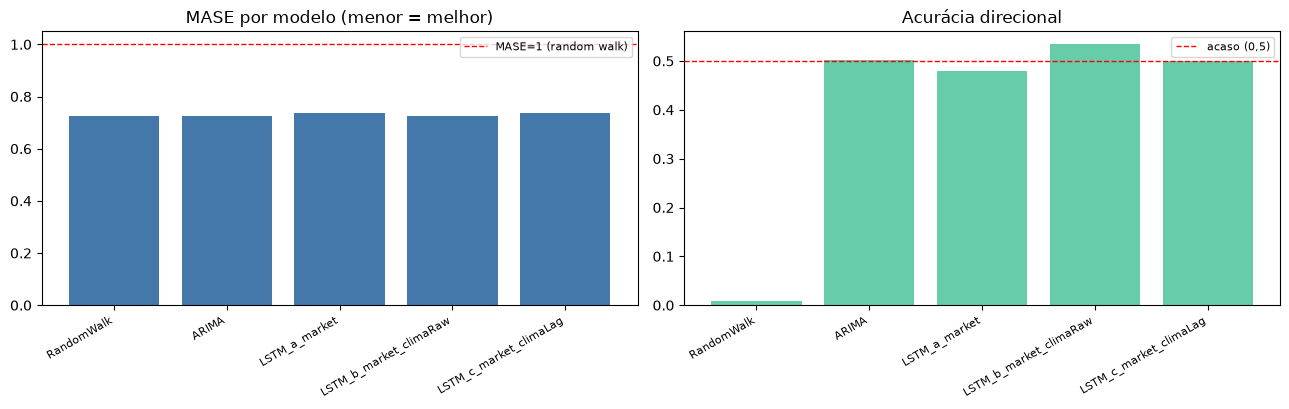

In [13]:
# Figura: barras de MASE e DirAcc por modelo
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
comp_plot = comp.reindex(order)
axes[0].bar(range(len(order)), comp_plot["MASE"].values, color="#4477aa")
axes[0].axhline(1.0, color="r", ls="--", lw=1, label="MASE=1 (random walk)")
axes[0].set_xticks(range(len(order))); axes[0].set_xticklabels(order, rotation=30, ha="right", fontsize=8)
axes[0].set_title("MASE por modelo (menor = melhor)"); axes[0].legend(fontsize=8)
axes[1].bar(range(len(order)), comp_plot["DirAcc"].values, color="#66ccaa")
axes[1].axhline(0.5, color="r", ls="--", lw=1, label="acaso (0,5)")
axes[1].set_xticks(range(len(order))); axes[1].set_xticklabels(order, rotation=30, ha="right", fontsize=8)
axes[1].set_title("Acurácia direcional"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/12_comparativo_baselines.png", dpi=DPI, bbox_inches="tight")
plt.show()

In [14]:
# Resumo automático (verdicto baseado nos números)
def verdict():
    lines = []
    base_rmse = comp.loc["RandomWalk", "RMSE"]
    best_lstm = comp.loc[["LSTM_a_market","LSTM_b_market_climaRaw","LSTM_c_market_climaLag"], "RMSE"].idxmin()
    a, b, c = "LSTM_a_market", "LSTM_b_market_climaRaw", "LSTM_c_market_climaLag"
    # 1) LSTM bate baselines?
    arima_rmse = comp.loc["ARIMA", "RMSE"]
    dm_best = comp.loc[best_lstm, "DM_oos_vs_naive"]
    lines.append(f"- **Melhor LSTM**: {best_lstm} (RMSE {comp.loc[best_lstm,'RMSE']:.5f}).")
    lines.append(f"- **vs random walk** (RMSE {base_rmse:.5f}): DM_oos = {dm_best:.2f} "
                 f"({'significativamente melhor' if dm_best < -1.96 else 'significativamente pior' if dm_best > 1.96 else 'sem diferença significativa'}).")
    dm_arima = comp.loc[best_lstm, "DM_oos_vs_ARIMA"]
    lines.append(f"- **vs ARIMA** (RMSE {arima_rmse:.5f}): DM_oos = {dm_arima:.2f} "
                 f"({'LSTM melhor' if dm_arima < -1.96 else 'LSTM pior' if dm_arima > 1.96 else 'sem diferença significativa'}).")
    # 2) clima ajuda?
    ra, rb, rc = comp.loc[a,"RMSE"], comp.loc[b,"RMSE"], comp.loc[c,"RMSE"]
    lines.append(f"- **Clima ajuda?** RMSE: só-mercado {ra:.5f} | +clima bruto {rb:.5f} | +clima defasado {rc:.5f}.")
    if min(rb, rc) < ra:
        which = "bruto" if rb < rc else "defasado"
        lines.append(f"  → adicionar clima ({which}) **reduziu** o RMSE médio.")
    else:
        lines.append("  → adicionar clima **não reduziu** o RMSE; as exógenas climáticas não agregaram poder preditivo neste protocolo.")
    return "\n".join(lines)

txt = verdict()
print(txt)
with open("results/resumo.md", "w") as fh:
    fh.write("# Resumo Fase 2 — baselines, ablação e seleção\n\n")
    fh.write("## Tabela comparativa\n\n")
    fh.write(comp.to_markdown() + "\n\n## Verdicto\n\n" + txt + "\n")
print("\nArtefatos salvos em results/ e figures/.")

- **Melhor LSTM**: LSTM_b_market_climaRaw (RMSE 0.02350).
- **vs random walk** (RMSE 0.02325): DM_oos = 1.38 (sem diferença significativa).
- **vs ARIMA** (RMSE 0.02325): DM_oos = 1.37 (sem diferença significativa).
- **Clima ajuda?** RMSE: só-mercado 0.02358 | +clima bruto 0.02350 | +clima defasado 0.02360.
  → adicionar clima (bruto) **reduziu** o RMSE médio.

Artefatos salvos em results/ e figures/.


# 10. Leitura
- **MASE < 1** e **DM_oos_vs_naive < −1,96** ⇒ habilidade real além do random walk.
- Em log-retorno diário de commodity é **esperado** que nem LSTM nem ARIMA batam o random walk
  de forma significativa — se for o caso, é resultado honesto a reportar.
- A ablação responde à pergunta central: o clima só agrega se **(b)** ou **(c)** baterem **(a)**
  de forma consistente. A seleção dentro do fold mostra **quais** features sobrevivem.